# K-Means Clustering from Scratch

The aim of this notebook is to implement **k-means** clustering algorithm from scratch using only NumPy.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

In [2]:
# Load synthetic dataset
n_samples = 300
X, y_true = make_blobs(n_samples=n_samples, centers=3, cluster_std=0.8, random_state=42)

In [3]:
# Centroids initialization
K = 3
indices = np.random.choice(n_samples, size=K, replace=False) # K random indices among n_samples
centroids = X[indices]

In [4]:
# Assign and update data points and centroids within clusters
def _assign_clusters(X, centroids):
    n_samples = X.shape[0]
    K = centroids.shape[0]
    labels = np.zeros(n_samples, dtype=int)
    
    for i in range(n_samples):
        # Compute the euclidian distance between X[i] and each centroids
        distances = np.linalg.norm(X[i] - centroids, axis=1)
        # Get the index of the closest centroid
        closest_centroid = np.argmin(distances)
        # Assign the label of the closest centroid to labels[i]
        labels[i] = closest_centroid
    
    return labels

In [5]:
# Update centroids by calculating the mean of the points assigned to each cluster
def _update_centroids(X, labels, K):
    n_features = X.shape[1]
    centroids = np.zeros((K, n_features))
    
    for k in range(K):
        # Get the points assigned to cluster k
        cluster_points = X[labels == k]
        # Update the centroid of cluster k as the mean of its points
        if len(cluster_points) > 0:
            centroids[k] = np.mean(cluster_points, axis=0)
    
    return centroids

In [6]:
# K-means main loop

# Initialize parameters
K = 3
n_iters = 100

# Initialize centroids randomly from the dataset
indices = np.random.choice(n_samples, size=K, replace=False)
centroids = X[indices]

# K-means iterations
for i in range(n_iters):
    # Step 1: Assign clusters
    labels = _assign_clusters(X, centroids)
    
    # Step 2: Update centroids
    new_centroids = _update_centroids(X, labels, K)
    
    # Check for convergence (stops if centroids do not change)
    if np.allclose(centroids, new_centroids):
        print(f"Converged after {i} iterations.")
        break
    
    centroids = new_centroids

Converged after 2 iterations.


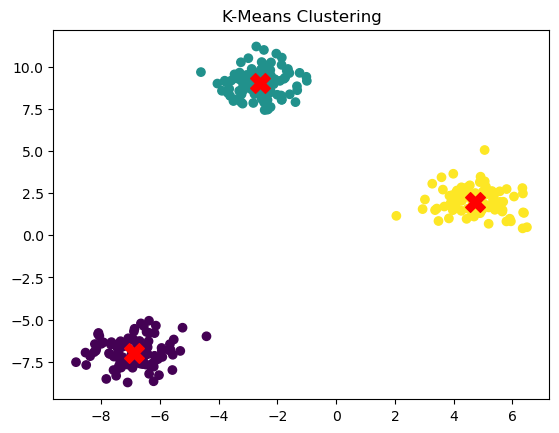

In [7]:
# Visualization
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200)
plt.title("K-Means Clustering")
plt.show()

The algorithm successfully identified the **3 clusters** generated by make_blobs.

In [8]:
# Inertia computation: computes the Within-Cluster Sum of Squares (WCSS) (see theory.md, section 3)
def _compute_inertia(X, labels, centroids):
    return np.sum(np.linalg.norm(X - centroids[labels], axis=1) ** 2)

Converged after 1 iterations.
Converged after 1 iterations.
Converged after 2 iterations.
Converged after 10 iterations.
Converged after 10 iterations.
Converged after 3 iterations.
Converged after 10 iterations.
Converged after 8 iterations.
Converged after 10 iterations.
Converged after 7 iterations.


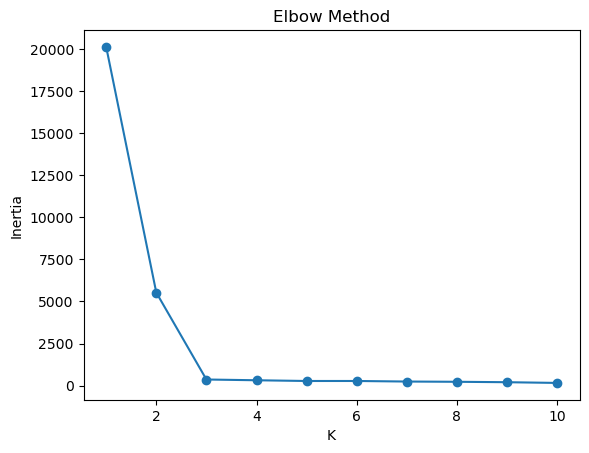

In [9]:
# Elbow method
n_iters = 100
inertias = []

for k in range(1, 11):
    # Initialize centroids with k 
    indices = np.random.choice(n_samples, size=k, replace=False)
    centroids = X[indices]
    
    # Complete k-means loop
    for i in range(n_iters):
        # Step 1: Assign clusters
        labels = _assign_clusters(X, centroids)
        
        # Step 2: Update centroids
        new_centroids = _update_centroids(X, labels, k)
        
        # Check for convergence (stops if centroids do not change)
        if np.allclose(centroids, new_centroids):
            print(f"Converged after {i} iterations.")
            break
        
        centroids = new_centroids

    # Compute inertia
    inertia = _compute_inertia(X, labels, centroids)

    # Store in inertias
    inertias.append(inertia)
    
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The **inflection point (elbow)** is indeed at K=3: the curve drops sharply from K=1 to K=3, then flattens out. The implementation is correct.

In [10]:
# Computation of silhouette score
score = silhouette_score(X, labels)
print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.323


**Note**:

The **silhouette score varies** between 0.36 and 0.54 depending on the initialization, and the elbow even shifted to K=4 in some runs. This is concrete evidence of the **sensitivity to random initialization**.

Also, on this second run, K=3 and K=4 have nearly identical inertia: a sign that two centroids were likely initialized in the same region and that the algorithm partitioned a blob incorrectly.

This is the direct motivation for n_init in the custom class where we will run the algorithm multiple times and keep the best result.